# Notebook 1 — Data Acquisition

Author: Eun-Kyeong Kim (eun-kyeong.kim@lxp.lu), LuxProvide S.A

## Multimodal Flood Inference with TerraMind on MeluXina HPC

**Goal:** Search Microsoft Planetary Computer's STAC catalogue for Sentinel-1 SAR,
Sentinel-2 optical, and Copernicus DEM tiles that cover the **2021 Luxembourg flood**
across four temporal phases (pre-month, pre-event, event, post-event). Save the selected
item IDs and asset URLs to a JSON manifest so that Notebook 2 can download and package
the data without re-querying the catalogue.

### What you will learn
- How a STAC catalogue is structured (collections → items → assets)
- How to filter satellite passes by date window, spatial overlap, and image quality
- How to serialise acquisition metadata for reproducible downstream processing

---


### 1 · Imports

We use:
- **`pystac_client`** — Python client for querying STAC catalogues
- **`planetary_computer`** — signs asset URLs so they are temporarily downloadable
- **`geopandas` / `shapely`** — work with geographic geometries
- **`pandas`** — tabular summaries of candidate satellite scenes


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import geopandas as gpd
import pandas as pd
import planetary_computer
import pystac_client
from shapely.geometry import box, shape
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### 2 · Configuration

All tunable parameters live here — change them once and the rest of the notebook
updates automatically.

| Variable | Meaning |
|---|---|
| `EVENT["bbox"]` | Bounding box of the study area in WGS-84 lon/lat |
| `EVENT["phase_dates"]` | One representative date per temporal phase |
| `S1_WINDOW_DAYS` | Half-width (days) of the search window around each phase date for S1 |
| `S2_WINDOW_DAYS` | Same for Sentinel-2 (wider because clouds reduce availability) |
| `S2_MAX_CLOUD` | Maximum allowed cloud-cover percentage for S2 scenes |


In [2]:
# ── Output paths ────────────────────────────────────────────────────────────
ROOT      = Path("data/terramind_flood_lux")   # top-level data folder
META_ROOT = ROOT / "metadata"                  # where the manifest JSON is saved
META_ROOT.mkdir(parents=True, exist_ok=True)

# ── Study-area and event definition ─────────────────────────────────────────
# The 2021 Luxembourg flood (July 14–15) was one of the worst in decades,
# caused by extreme rainfall in the Ahr–Moselle catchment.
EVENT = {
    "name": "luxembourg_flood_2021_multimodal",
    # [west, south, east, north] in WGS-84 degrees
    "bbox": [5.7333, 49.4426, 6.5282, 50.1830],
    # UTM zone 32N — the projected CRS used for raster packaging in Notebook 2
    "target_crs": "EPSG:32632",
    # One representative date per temporal phase
    "phase_dates": {
        "pre_month":  "2021-06-15",   # ~30 days before the flood peak
        "pre_event":  "2021-07-11",   # a few days before the flood
        "event":      "2021-07-15",   # peak flood day
        "post_event": "2021-07-18",   # early recovery
    },
}

# Fixed order — critical for aligning array time-steps later
PHASE_ORDER = ["pre_month", "pre_event", "event", "post_event"]

# ── STAC collection identifiers ──────────────────────────────────────────────
S1_COLLECTION  = "sentinel-1-rtc"     # Sentinel-1 Radiometrically Terrain Corrected
S2_COLLECTION  = "sentinel-2-l2a"     # Sentinel-2 Level-2A (surface reflectance)
DEM_COLLECTION = "cop-dem-glo-30"     # Copernicus GLO-30 Digital Elevation Model

# ── Band / asset lists ───────────────────────────────────────────────────────
# These are the asset keys used by Planetary Computer for each collection.
S1_ASSETS = ["vv", "vh"]              # dual-polarisation SAR backscatter
S2_ASSETS = [                         # 12 multispectral bands (10–60 m native)
    "B01", "B02", "B03", "B04",
    "B05", "B06", "B07", "B08",
    "B8A", "B09", "B11", "B12",
]

# ── Search window parameters ─────────────────────────────────────────────────
# Half-width in days: search ±N days around each phase date.
# SAR scenes are available every ~6 days, so a 4-day window is usually enough.
# Optical scenes may be cloudy, so we use a wider window for S2.
S1_WINDOW_DAYS = 4
S2_WINDOW_DAYS = 10
S2_MAX_CLOUD   = 25.0   # reject S2 scenes with >25 % cloud cover

# ── Convenience: Region-of-Interest as a GeoDataFrame ────────────────────────
roi_geom = box(*EVENT["bbox"])                                # Shapely Polygon
roi_gdf  = gpd.GeoDataFrame({"geometry": [roi_geom]}, crs="EPSG:4326")
roi_gdf

,geometry
0,"POLYGON ((6.5282 49.4426, 6.5282 50.183, 5.733..."


##### Visualize the Region of Interest (covering Luxembourg) 

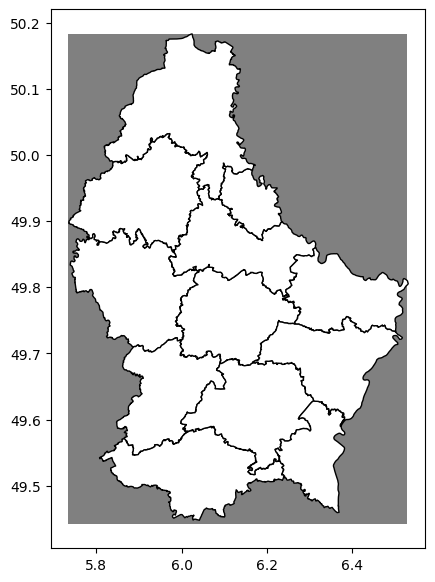

In [3]:
# 1. Read the GeoJSON file into a GeoDataFrame
admin_geojson = 'https://download.data.public.lu/resources/limites-administratives-du-grand-duche-de-luxembourg/20260405-030017/limadmin.geojson'
admin_gdf = gpd.read_file(admin_geojson)

# 2. Ensure both are in the same CRS (crucial step!)
if admin_gdf.crs != roi_gdf.crs:
    admin_gdf = admin_gdf.to_crs(roi_gdf.crs)

# 3. Plot together (Overlay)
fig, ax = plt.subplots(figsize=(7, 7))

roi_gdf.plot(ax=ax, color='gray', markersize=5)
admin_gdf.plot(ax=ax, color='white', edgecolor='black')

plt.show()

### 3 · STAC catalogue connection and search helpers

**How STAC works:**
A STAC *catalogue* is a web API that lists satellite imagery as *items*. Each item
has a geometry, a date, and a set of named *assets* (the actual file URLs). We open
the Planetary Computer catalogue and define helper functions to:

1. Build a date-range string for the search window.
2. Compute how much of our region-of-interest (ROI) each candidate scene covers.
3. Score and rank candidates so we always pick the "best" scene per phase.


In [4]:
# Open the Planetary Computer STAC catalogue.
# `modifier=planetary_computer.sign_inplace` automatically signs asset URLs
# so they can be downloaded without manual authentication.
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


def phase_window(date_str: str, half_window_days: int) -> str:
    """Return an ISO-8601 datetime interval string centred on *date_str*.

    Example: phase_window("2021-07-15", 4)
             → "2021-07-11T00:00:00Z/2021-07-19T23:59:59Z"
    """
    ts    = pd.Timestamp(date_str, tz="UTC")
    start = (ts - pd.Timedelta(days=half_window_days)).strftime("%Y-%m-%dT00:00:00Z")
    end   = (ts + pd.Timedelta(days=half_window_days)).strftime("%Y-%m-%dT23:59:59Z")
    return f"{start}/{end}"


def item_geometry(item):
    """Extract a Shapely geometry from a STAC item (prefers .geometry over .bbox)."""
    if item.geometry is not None:
        return shape(item.geometry)
    return box(*item.bbox)


def overlap_fraction(item, roi_polygon):
    """Return the fraction of *roi_polygon* that is covered by *item*'s footprint.

    A value of 1.0 means the scene fully covers the ROI.
    """
    scene_geom = item_geometry(item)
    if scene_geom.is_empty:
        return 0.0
    intersection = scene_geom.intersection(roi_polygon)
    return float(intersection.area / roi_polygon.area)


def safe_timestamp(value):
    """Parse a datetime string to a timezone-aware Timestamp; return NaT on failure."""
    return pd.to_datetime(value, utc=True, errors="coerce")


# ── Scene-scoring functions ──────────────────────────────────────────────────
# We want: maximum overlap, minimum distance to the target date, and (for S2)
# minimum cloud cover.  Sorting by `score_tuple` puts the best candidate first.

def s1_score(item, phase_date: str) -> dict:
    """Compute a sortable score for a Sentinel-1 RTC scene.

    Priority (ascending): higher overlap first, then closer to the phase date.
    """
    props    = item.properties
    dt       = safe_timestamp(props.get("datetime") or props.get("start_datetime"))
    target   = pd.Timestamp(phase_date, tz="UTC")
    days_off = abs((dt.normalize() - target.normalize()).days) if pd.notnull(dt) else 999
    overlap  = overlap_fraction(item, roi_geom)
    return {
        "item":            item,
        "datetime":        dt,
        "days_from_phase": days_off,
        "aoi_overlap_frac": overlap,
        "relative_orbit":  props.get("sat:relative_orbit"),
        "orbit_state":     props.get("sat:orbit_state"),
        # Tuple used for sorting: negate overlap so that larger → lower sort key
        "score_tuple": (-overlap, days_off, str(dt),
                        str(props.get("sat:relative_orbit")),
                        str(props.get("sat:orbit_state"))),
    }


def s2_score(item, phase_date: str) -> dict:
    """Compute a sortable score for a Sentinel-2 L2A scene.

    Priority: higher overlap first, then lower cloud cover, then closer date.
    """
    props    = item.properties
    dt       = safe_timestamp(props.get("datetime") or props.get("start_datetime"))
    target   = pd.Timestamp(phase_date, tz="UTC")
    days_off = abs((dt.normalize() - target.normalize()).days) if pd.notnull(dt) else 999
    overlap  = overlap_fraction(item, roi_geom)
    cloud    = float(props.get("eo:cloud_cover", 1000.0))
    return {
        "item":             item,
        "datetime":         dt,
        "days_from_phase":  days_off,
        "aoi_overlap_frac": overlap,
        "eo:cloud_cover":   cloud,
        "score_tuple": (-overlap, cloud, days_off, str(dt)),
    }


def search_phase_items(collection: str, phase_date: str,
                       half_window_days: int, query: dict | None = None):
    """Query the STAC catalogue and return all matching items as a list."""
    search = catalog.search(
        collections=[collection],
        bbox=EVENT["bbox"],
        datetime=phase_window(phase_date, half_window_days),
        query=query or {},
    )
    return list(search.items())

### 4 · Select best S1 and S2 scenes for each phase

For each of the four temporal phases we:

1. Query the catalogue within the date window.
2. Keep only candidates that have **all required assets** (band files present).
3. Score and sort the candidates.
4. Pick the top-ranked scene.

This loop populates two summary tables — `s1_df` and `s2_df` — that list the
chosen scenes with their quality metrics.


In [5]:
s1_rows = []  # will hold one dict per phase
s2_rows = []

for phase in PHASE_ORDER:
    phase_date = EVENT["phase_dates"][phase]

    # ── Sentinel-1 ────────────────────────────────────────────────────────
    # Require dual-polarisation (VV + VH) acquisitions only.
    s1_items = search_phase_items(
        S1_COLLECTION,
        phase_date=phase_date,
        half_window_days=S1_WINDOW_DAYS,
        query={"sar:polarizations": {"eq": ["VV", "VH"]}},
    )

    # Filter to scenes that actually contain both VV and VH asset files,
    # then score and rank.
    s1_candidates = [
        s1_score(item, phase_date)
        for item in s1_items
        if all(k in item.assets for k in S1_ASSETS)
    ]
    s1_candidates.sort(key=lambda r: r["score_tuple"])

    if not s1_candidates:
        raise RuntimeError(f"No S1 RTC candidates found for phase '{phase}'. "
                           "Try widening S1_WINDOW_DAYS.")

    best_s1 = s1_candidates[0]
    s1_rows.append({
        "phase":            phase,
        "collection":       S1_COLLECTION,
        "id":               best_s1["item"].id,
        "datetime":         best_s1["datetime"],
        "days_from_phase":  best_s1["days_from_phase"],
        "aoi_overlap_frac": best_s1["aoi_overlap_frac"],
        "orbit_state":      best_s1["orbit_state"],
        "relative_orbit":   best_s1["relative_orbit"],
        # Signed download URLs — used by Notebook 2
        "vv_href":          best_s1["item"].assets["vv"].href,
        "vh_href":          best_s1["item"].assets["vh"].href,
    })

    # ── Sentinel-2 ────────────────────────────────────────────────────────
    s2_items = search_phase_items(
        S2_COLLECTION,
        phase_date=phase_date,
        half_window_days=S2_WINDOW_DAYS,
        query={"eo:cloud_cover": {"lt": S2_MAX_CLOUD}},
    )

    s2_candidates = [
        s2_score(item, phase_date)
        for item in s2_items
        if all(k in item.assets for k in S2_ASSETS)
    ]
    s2_candidates.sort(key=lambda r: r["score_tuple"])

    if not s2_candidates:
        raise RuntimeError(f"No S2 L2A candidates found for phase '{phase}'. "
                           "Try increasing S2_MAX_CLOUD or widening S2_WINDOW_DAYS.")

    best_s2 = s2_candidates[0]
    s2_rows.append({
        "phase":            phase,
        "collection":       S2_COLLECTION,
        "id":               best_s2["item"].id,
        "datetime":         best_s2["datetime"],
        "days_from_phase":  best_s2["days_from_phase"],
        "aoi_overlap_frac": best_s2["aoi_overlap_frac"],
        "eo:cloud_cover":   best_s2["eo:cloud_cover"],
        # One signed URL per spectral band
        **{f"{band}_href": best_s2["item"].assets[band].href for band in S2_ASSETS},
    })

# ── Display summary tables ────────────────────────────────────────────────
s1_df = pd.DataFrame(s1_rows).sort_values("phase").reset_index(drop=True)
s2_df = pd.DataFrame(s2_rows).sort_values("phase").reset_index(drop=True)

print("Selected Sentinel-1 scenes:")
display(s1_df[["phase", "id", "datetime", "days_from_phase",
               "aoi_overlap_frac", "orbit_state"]])

print("\nSelected Sentinel-2 scenes:")
display(s2_df[["phase", "id", "datetime", "days_from_phase",
               "aoi_overlap_frac", "eo:cloud_cover"]])

Selected Sentinel-1 scenes:


,phase,id,datetime,days_from_phase,aoi_overlap_frac,orbit_state
0,event,S1A_IW_GRDH_1SDV_20210715T055052_20210715T0551...,2021-07-15 05:51:04.897499+00:00,0,1.0,descending
1,post_event,S1A_IW_GRDH_1SDV_20210715T055052_20210715T0551...,2021-07-15 05:51:04.897499+00:00,3,1.0,descending
2,pre_event,S1A_IW_GRDH_1SDV_20210710T054242_20210710T0543...,2021-07-10 05:42:54.536403+00:00,1,1.0,descending
3,pre_month,S1A_IW_GRDH_1SDV_20210616T054240_20210616T0543...,2021-06-16 05:42:53.246501+00:00,1,1.0,descending



Selected Sentinel-2 scenes:


,phase,id,datetime,days_from_phase,aoi_overlap_frac,eo:cloud_cover
0,event,S2A_MSIL2A_20210721T104031_R008_T31UGR_2021072...,2021-07-21 10:40:31.024000+00:00,6,0.840362,3.280537
1,post_event,S2A_MSIL2A_20210721T104031_R008_T31UGR_2021072...,2021-07-21 10:40:31.024000+00:00,3,0.840362,3.280537
2,pre_event,S2A_MSIL2A_20210721T104031_R008_T31UGR_2021072...,2021-07-21 10:40:31.024000+00:00,10,0.840362,3.280537
3,pre_month,S2A_MSIL2A_20210611T104021_R008_T31UGR_2021062...,2021-06-11 10:40:21.024000+00:00,4,0.840362,16.999946


### 5 · Collect DEM tiles

The Copernicus GLO-30 DEM comes in 1°×1° tiles. Several tiles may be needed to
cover the full ROI — we record all of them so Notebook 2 can mosaic them.


In [6]:
# Search for all DEM tiles that overlap the ROI (no date filter needed — DEM is static).
dem_items = list(
    catalog.search(
        collections=[DEM_COLLECTION],
        bbox=EVENT["bbox"],
    ).items()
)

# Keep only tiles with non-zero overlap; sort by overlap fraction for reference.
dem_rows = []
for item in dem_items:
    frac = overlap_fraction(item, roi_geom)
    if frac <= 0:
        continue
    dem_rows.append({
        "collection":       DEM_COLLECTION,
        "id":               item.id,
        "aoi_overlap_frac": frac,
        "data_href":        item.assets["data"].href,
    })

dem_df = (pd.DataFrame(dem_rows)
            .sort_values("aoi_overlap_frac", ascending=False)
            .reset_index(drop=True))
print(f"Found {len(dem_df)} DEM tile(s) covering the ROI.")
dem_df

Found 4 DEM tile(s) covering the ROI.


,collection,id,aoi_overlap_frac,data_href
0,cop-dem-glo-30,Copernicus_DSM_COG_10_N49_00_E006_00_DEM,0.500505,https://elevationeuwest.blob.core.windows.net/...
1,cop-dem-glo-30,Copernicus_DSM_COG_10_N49_00_E005_00_DEM,0.252518,https://elevationeuwest.blob.core.windows.net/...
2,cop-dem-glo-30,Copernicus_DSM_COG_10_N50_00_E006_00_DEM,0.164177,https://elevationeuwest.blob.core.windows.net/...
3,cop-dem-glo-30,Copernicus_DSM_COG_10_N50_00_E005_00_DEM,0.082799,https://elevationeuwest.blob.core.windows.net/...


### 6 · Save acquisition manifest

The manifest is a single JSON file that records every decision made in this notebook:
which scenes were chosen, their metadata, and the signed download URLs. Notebook 2
reads this file to know exactly which data to download — no need to re-query the
catalogue.


In [7]:
manifest = {
    "event":        EVENT,
    "phase_order":  PHASE_ORDER,
    "collections": {
        "S1RTC": S1_COLLECTION,
        "S2L2A": S2_COLLECTION,
        "DEM":   DEM_COLLECTION,
    },
    "assets": {
        "S1RTC": S1_ASSETS,
        "S2L2A": S2_ASSETS,
        "DEM":   ["data"],
    },
    "selected":  {},   # best scene per phase per sensor
    "dem_items": [],   # all DEM tiles needed for the ROI
}

# ── Populate S1 entries ───────────────────────────────────────────────────
for row in s1_rows:
    phase = row["phase"]
    manifest["selected"].setdefault(phase, {})
    manifest["selected"][phase]["S1RTC"] = {
        "collection":       row["collection"],
        "id":               row["id"],
        "datetime":         pd.Timestamp(row["datetime"]).isoformat(),
        "days_from_phase":  int(row["days_from_phase"]),
        "aoi_overlap_frac": float(row["aoi_overlap_frac"]),
        "orbit_state":      row["orbit_state"],
        "relative_orbit":   None if pd.isna(row["relative_orbit"])
                            else int(row["relative_orbit"]),
    }

# ── Populate S2 entries ───────────────────────────────────────────────────
for row in s2_rows:
    phase = row["phase"]
    manifest["selected"].setdefault(phase, {})
    manifest["selected"][phase]["S2L2A"] = {
        "collection":       row["collection"],
        "id":               row["id"],
        "datetime":         pd.Timestamp(row["datetime"]).isoformat(),
        "days_from_phase":  int(row["days_from_phase"]),
        "aoi_overlap_frac": float(row["aoi_overlap_frac"]),
        "eo:cloud_cover":   float(row["eo:cloud_cover"]),
    }

# ── Populate DEM entries ──────────────────────────────────────────────────
for row in dem_rows:
    manifest["dem_items"].append({
        "collection":       row["collection"],
        "id":               row["id"],
        "aoi_overlap_frac": float(row["aoi_overlap_frac"]),
    })

# ── Write to disk ─────────────────────────────────────────────────────────
manifest_path = META_ROOT / "multimodal_acquisition_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print(f"Manifest saved → {manifest_path}")
print(f"  Phases recorded : {list(manifest['selected'].keys())}")
print(f"  DEM tiles found : {len(manifest['dem_items'])}")

Manifest saved → data/terramind_flood_lux/metadata/multimodal_acquisition_manifest.json
  Phases recorded : ['pre_month', 'pre_event', 'event', 'post_event']
  DEM tiles found : 4
